# SAT formula generator

In [1]:
import random
import math
import numpy as np

class kSATGenerator:
    def __init__(self, num_clauses, num_vars, k, seed=None):
        self.num_clauses = num_clauses
        self.num_vars = num_vars
        self.k = k
        self.random = random.Random(seed)

    def generate(self):
        max_num_clauses = 2**self.k * math.comb(self.num_vars, self.k)
        if self.num_clauses > max_num_clauses:
            raise ValueError("Too many clauses")
        
        vars_list = list(range(1, self.num_vars + 1))
        clauses = set()

        while len(clauses) < self.num_clauses:
            variables = sorted(self.random.sample(vars_list, self.k))
            literals = [var * self.random.choice([1, -1]) for var in variables]
            clause = tuple(literals)
            clauses.add(clause)

        return list(clauses)
    
class Pos1in2SATGenerator:
    def __init__(self, num_clauses, num_vars, k, seed=None):
        self.num_clauses = num_clauses
        self.num_vars = num_vars
        self.k = k
        self.random = random.Random(seed)

    def generate(self):
        max_num_clauses = math.comb(self.num_vars, self.k)
        if self.num_clauses > max_num_clauses:
            raise ValueError("Too many clauses")
        
        vars_list = list(range(1, self.num_vars + 1))
        clauses = set()

        while len(clauses) < self.num_clauses:
            variables = sorted(self.random.sample(vars_list, self.k))
            literals = variables
            clause = tuple(literals)
            clauses.add(clause)

        return list(clauses)


threesat_generator = kSATGenerator(5, 4, 3, seed=42)
formula = threesat_generator.generate()
print(formula)

pos1in2sat_generator = Pos1in2SATGenerator(5, 4, 2, seed=42)
formula = pos1in2sat_generator.generate()
print(formula)

[(2, 3, -4), (-1, 3, 4), (1, -2, 3), (1, 3, -4), (1, 2, 4)]
[(1, 2), (3, 4), (1, 4), (2, 3), (1, 3)]


# Utilities functions on formulas

In [2]:
def get_num_clauses(formula):
    return len(formula)

def get_num_variables(formula):
    return int(np.max(np.abs(np.array(formula).flatten()))) # cast to int to avoid fixed size np.int64

def get_k(formula):
    return len(formula[0])

## Brute force solver

In [3]:
def brute_force_solve(formula, one_in_k=False):
    num_variables = get_num_variables(formula)
    for n in range(2**num_variables):
        #bitstring = [(n >> i) & 1 for i in reversed(range(num_variables))]
        violated_count = 0
        for clause in formula:
            true_count = 0
            for literal in clause:
                var_index = abs(literal) - 1
                #value = bitstring[var_index] if literal > 0 else 1 - bitstring[var_index]
                value = (n >> (num_variables - 1 - var_index)) & 1
                if literal < 0:
                    value = 1 - value
                    
                true_count += value
            if one_in_k:
                if true_count != 1:
                    violated_count += 1
            else:
                if true_count == 0:
                    violated_count += 1
        if violated_count == 0:
            bitstring = [(n >> i) & 1 for i in reversed(range(num_variables))]
            return list(bitstring)
    return None

# Formula evaluator

In [4]:
def count_violated_clauses(formula, bitstring, one_in_k=False):
    violated_count = 0
    for clause in formula:
        true_literals_count = 0
        for literal in clause:
            var_index = abs(literal) - 1
            var_value = bitstring[var_index] if literal > 0 else (1 - bitstring[var_index])
            true_literals_count += var_value

        if one_in_k:
            if true_literals_count != 1: # exactly one True needed
                violated_count += 1
        else:
            if true_literals_count == 0: # at least one True needed
                violated_count += 1
    return violated_count

bitstring = [1,0,0,1]
print(count_violated_clauses(formula, bitstring, one_in_k=False))
print(count_violated_clauses(formula, bitstring, one_in_k=True))

1
2


# Test cases

In [5]:
test_cases = [
    ([(1, 2), (-1, 3)], [1, 0, 1], False, 0),
    ([(1, 2), (-1, 3)], [0, 0, 1], False, 1),
    ([(1, 2), (-1, 3)], [0, 0, 0], False, 1),
    ([(-1, -2)], [0, 1], False, 0),
    ([(-1, -2)], [1, 1], False, 1),
    ([(1, 2, 3)], [1, 0, 0], True, 0),
    ([(1, 2, 3)], [0, 0, 0], True, 1),
    ([(1, 2, 3)], [1, 1, 0], True, 1),
    ([(1, -2), (2, 3, -1)], [1, 0, 0], True, 2),
    ([(-1, 2, -3)], [1, 0, 0], True, 0),
    ([(-1, 2, -3)], [1, 1, 0], True, 1),
]

for i, (formula, bitstring, one_in_k, expected) in enumerate(test_cases, 1):
    result = count_violated_clauses(formula, bitstring, one_in_k)
    assert result == expected, f"Test case {i} failed: got {result}, expected {expected}"


def test_random_bruteforce(num_tests=5, num_clauses=3, num_vars=4, k=3, one_in_k=False, seed=None):
    sat_generator = kSATGenerator(num_clauses, num_vars, k, seed)
    
    for i in range(num_tests):
        formula = sat_generator.generate()
        solution = brute_force_solve(formula, one_in_k=one_in_k)
        
        
        if solution is not None:
            violated_count = count_violated_clauses(formula, solution, one_in_k)
            assert violated_count == 0, f"Test {i+1} failed: solution violates {violated_count} clauses"
    
    print("All tests passed")


test_random_bruteforce(num_tests=20, k=3, one_in_k=False)
test_random_bruteforce(num_tests=20, k=3, one_in_k=True)
    

All tests passed
All tests passed


# Hamiltonian calculator

In [6]:
from scipy.sparse import diags

def ksat_hamiltonian(formula):
    n_vars = get_num_variables(formula)

    dim = 2 ** n_vars
    H_diag = np.zeros(dim, dtype=int)

    for clause in formula:
        ith_term = np.ones(2 ** n_vars, dtype=int)
        for literal in clause:
            variable_idx = np.abs(literal) - 1
            
            states = np.arange(dim)
            bits = (states >> variable_idx) & 1
            if literal > 0:
                proj = 1 - bits
            else:
                proj = bits
            ith_term *= proj
        H_diag += ith_term
    H = diags(H_diag, 0, format='csr')
    return H

    

## Test Hamiltonian calculator

In [7]:
test_sat_generator = kSATGenerator(20, 20, 3, seed=42)
formula = test_sat_generator.generate()
print("formula: ", formula)
n_vars = get_num_variables(formula)
print("n_vars: ", n_vars)
dim = 2 ** n_vars
print("dim: ", dim)

H = ksat_hamiltonian(formula)
H_diag = H.diagonal()
assert len(H_diag) == dim
print("Hamiltonian: ", H_diag)

for state in range(dim):
    # Convert state to bitstring
    bitstring = [(state >> i) & 1 for i in range(n_vars)]
    violated = count_violated_clauses(formula, bitstring)
    assert H_diag[state] == count_violated_clauses(formula, bitstring)
    #print(f"{bitstring} | {H_diag[state]} | {violated}")

formula:  [(-3, -4, -13), (3, 7, 9), (9, -12, -15), (7, -11, -19), (5, 9, -15), (-3, 4, 18), (3, 16, 17), (-3, -6, -14), (10, 12, 18), (2, -15, 18), (8, 9, -15), (3, 7, -8), (9, -13, 15), (-13, 14, 19), (-4, 10, -11), (1, 4, 9), (5, -9, 11), (3, 8, -10), (-2, -8, 11), (9, 17, -18)]
n_vars:  19
dim:  524288
Hamiltonian:  [4. 3. 4. ... 2. 2. 2.]


# List generator for SparsePauliOp

$H_{C, k} = \frac{1}{2^k} \sum_{a=1}^m \prod_{l=1}^k (1+A_{a_l, a} Z_{a_l})$

$H_{C, 2^+} = \frac{1}{4} \sum_{a=1}^m (Z_{a_1} + Z_{a_2})^2 = \frac{1}{2} \sum_{a=1}^m (1 + Z_{a_1} Z_{a_2})$

$H_{C, 3^+} = \frac{1}{4} \sum_{a=1}^m (Z_{a_1} + Z_{a_2} + Z_{a_3} - 1)^2$

In [8]:
def sparse_pauli_list_pos1in2sat(formula):
    assert get_k(formula) == 2
    n_vars = get_num_variables(formula)
    
    coeffs = {}

    def add_term(z_vars, coeff):
        string = ['I'] * n_vars
        for x in z_vars:
            string[-x] = 'Z'
        string = "".join(string)
        coeffs[string] = coeffs.get(string, 0) + coeff

    for (lit1, lit2) in formula:
        sgn1, sgn2 = int(np.sign(lit1)), int(np.sign(lit2))
        assert sgn1==1 and sgn2==1
        var1, var2 = np.abs(lit1), np.abs(lit2)

        add_term([], 1)
        add_term([var1, var2], 1)

    return [(pauli, coeff / 2) for pauli, coeff in coeffs.items() if coeff != 0]


def sparse_pauli_list_2sat(formula):
    assert get_k(formula) == 2
    n_vars = get_num_variables(formula)
    
    coeffs = {}

    def add_term(z_vars, coeff):
        string = ['I'] * n_vars
        for x in z_vars:
            string[-x] = 'Z'
        string = "".join(string)
        coeffs[string] = coeffs.get(string, 0) + coeff

    for (lit1, lit2) in formula:
        sgn1, sgn2 = int(np.sign(lit1)), int(np.sign(lit2))
        var1, var2 = np.abs(lit1), np.abs(lit2)

        add_term([], 1)
        add_term([var1], sgn1)
        add_term([var2], sgn2)
        add_term([var1, var2], sgn1*sgn2)

    return [(pauli, coeff / 4) for pauli, coeff in coeffs.items() if coeff != 0]
    

assert sorted(sparse_pauli_list_2sat([(1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', 0.25), ('ZZ', 0.25)])
assert sorted(sparse_pauli_list_2sat([(-1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', -0.25), ('ZZ', -0.25)])
assert sorted(sparse_pauli_list_2sat([(1, 2), (-1, 2)])) == sorted([('II', 0.5), ('ZI', 0.5)])

assert sorted(sparse_pauli_list_2sat([(-2, -4)])) == sorted([('IIII', 0.25), ('IIZI', -0.25), ('ZIII', -0.25), ('ZIZI', 0.25)])
assert sorted(sparse_pauli_list_2sat([(-1, 4)])) == sorted([('IIII', 0.25), ('IIIZ', -0.25), ('ZIII', 0.25), ('ZIIZ', -0.25)])
assert sorted(sparse_pauli_list_2sat([(-2, -4), (-1, 4)])) == sorted([('IIII', 0.5), ('IIZI', -0.25), ('IIIZ', -0.25), ('ZIZI', 0.25), ('ZIIZ', -0.25)])

# TODO::: test cases for positive in 1 2 sat


In [9]:

def sparse_pauli_list_ksat(formula):
    k = get_k(formula)
    n_vars = get_num_variables(formula)

    coeffs = {}

    def add_term(z_vars, coeff):
        string = ['I'] * n_vars
        for q in z_vars:
            string[-q] = 'Z'
        string = "".join(string)
        coeffs[string] = coeffs.get(string, 0) + coeff

    for clause in formula:
        terms = [(1, [])]
        # Multiply by (1 + s_i Z_i)
        for lit in clause:
            sgn = int(np.sign(lit))
            var = abs(lit)
            new_terms = []
            for coeff, z_vars in terms:
                # Multiply by 1
                new_terms.append((coeff, z_vars))
                # Multiply by s_i Z_i
                new_terms.append((coeff * sgn, z_vars + [var]))
            terms = new_terms

        # Add to global coeffs
        for coeff, z_vars in terms:
            add_term(z_vars, coeff)

    return [(pauli, coeff / 2 ** k) for pauli, coeff in coeffs.items() if coeff != 0]

assert sorted(sparse_pauli_list_ksat([(1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', 0.25), ('ZZ', 0.25)])
assert sorted(sparse_pauli_list_ksat([(-1, 2)])) == sorted([('II', 0.25), ('ZI', 0.25), ('IZ', -0.25), ('ZZ', -0.25)])
assert sorted(sparse_pauli_list_ksat([(1, 2), (-1, 2)])) == sorted([('II', 0.5), ('ZI', 0.5)])

assert sorted(sparse_pauli_list_ksat([(-2, -4)])) == sorted([('IIII', 0.25), ('IIZI', -0.25), ('ZIII', -0.25), ('ZIZI', 0.25)])
assert sorted(sparse_pauli_list_ksat([(-1, 4)])) == sorted([('IIII', 0.25), ('IIIZ', -0.25), ('ZIII', 0.25), ('ZIIZ', -0.25)])
assert sorted(sparse_pauli_list_ksat([(-2, -4), (-1, 4)])) == sorted([('IIII', 0.5), ('IIZI', -0.25), ('IIIZ', -0.25), ('ZIZI', 0.25), ('ZIIZ', -0.25)])

# TODO:: tests for 3-sat, +


# Qiskit

C:\Users\dev\AppData\Local\Temp\ipykernel_5804\1632495220.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit.quantum_info import SparsePauliOp


[(2, 3, -4), (-1, 3, 4), (1, -2, 3), (1, 3, -4), (1, 2, 4)]
[('IIII', 0.625), ('IZII', 0.5), ('ZZII', -0.125), ('IIZI', 0.125), ('ZZZI', -0.125), ('IIIZ', 0.25), ('ZIIZ', -0.125), ('IZIZ', 0.125), ('ZZIZ', -0.25), ('IZZZ', -0.125), ('ZIZZ', 0.125)]
SparsePauliOp(['IIII', 'IZII', 'ZZII', 'IIZI', 'ZZZI', 'IIIZ', 'ZIIZ', 'IZIZ', 'ZZIZ', 'IZZZ', 'ZIZZ'],
              coeffs=[ 0.625+0.j,  0.5  +0.j, -0.125+0.j,  0.125+0.j, -0.125+0.j,  0.25 +0.j,
 -0.125+0.j,  0.125+0.j, -0.25 +0.j, -0.125+0.j,  0.125+0.j])


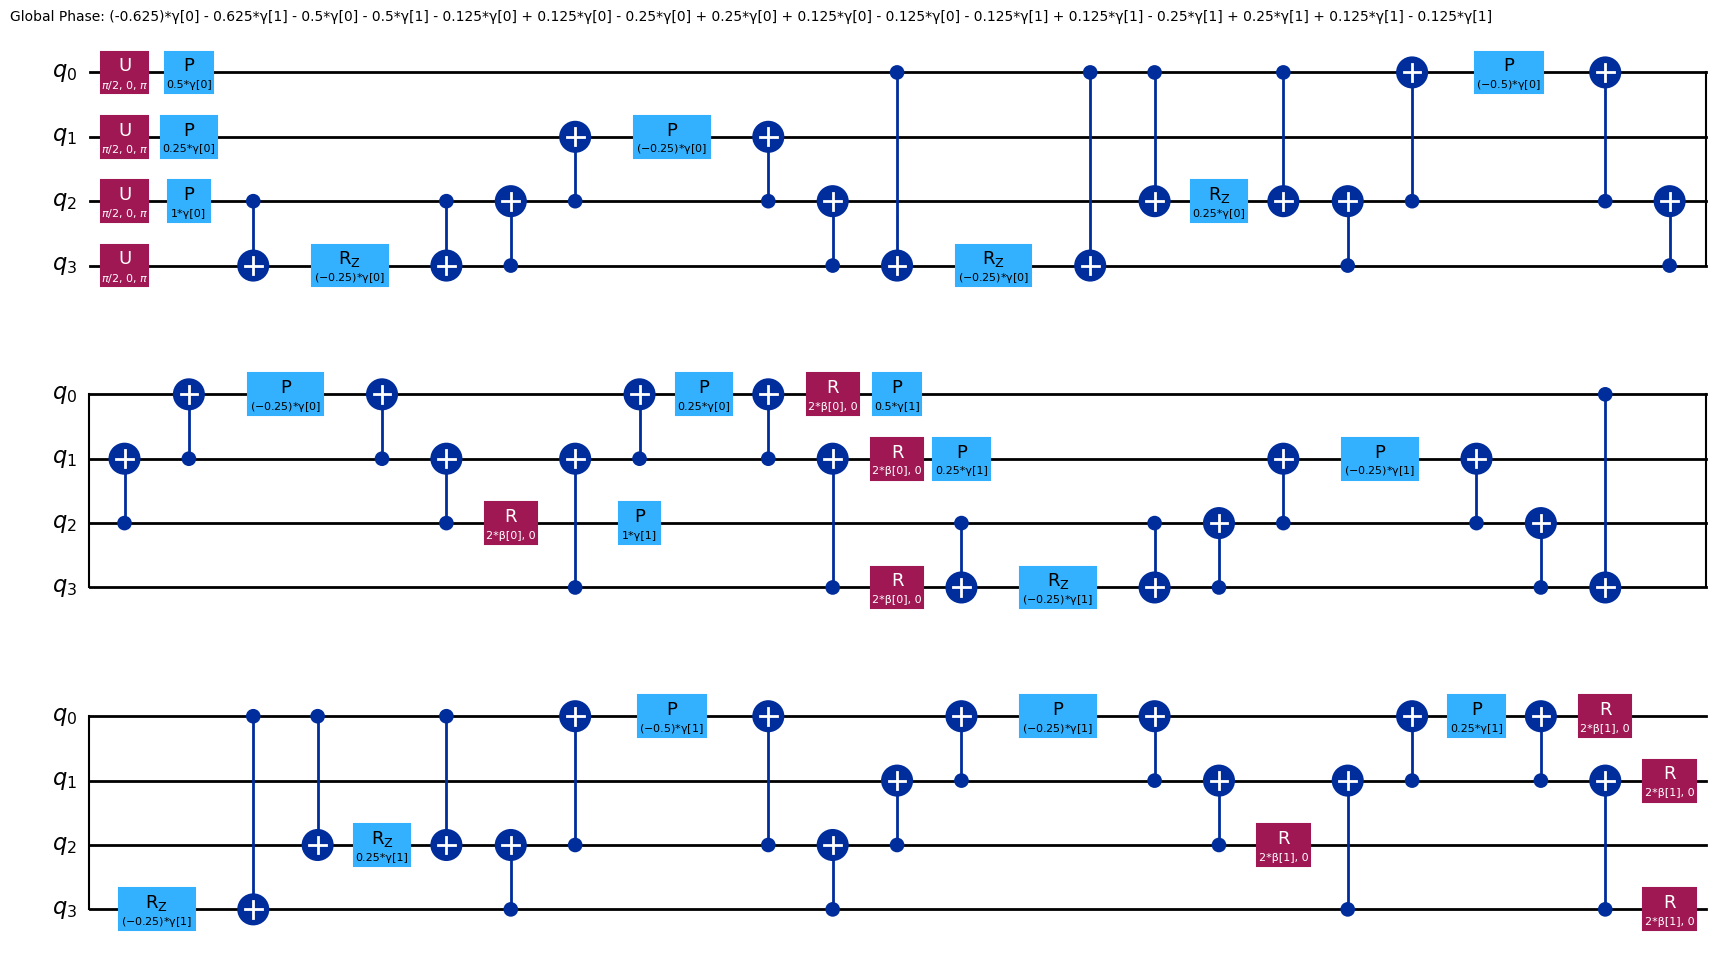

In [10]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz

sat3_generator = kSATGenerator(5, 4, 3, seed=42)
formula = sat3_generator.generate()
print(formula)

sparse_pauli_list = sparse_pauli_list_ksat(formula)
print(sparse_pauli_list)

cost_hamiltonian = SparsePauliOp.from_list(sparse_pauli_list)
print(cost_hamiltonian)

ansatz = QAOAAnsatz(cost_hamiltonian, reps=2)
ansatz.decompose(reps=3).draw("mpl")